# Credit Card Fraud Detection - PCA Encrypted Dataset

**Dataset Overview & Anomaly Detection:**
This dataset contains credit card transactions, and the primary goal is anomaly detection (identifying fraudulent transactions among legitimate ones).
Due to confidentiality and privacy concerns, the dataset is a **PCA (Principal Component Analysis) encrypted dataset**. 
- The original features are not provided.
- Features `V1`, `V2`, ... `V28` are the principal components obtained through the PCA transformation.
- The only features that have not been transformed are `Time` (seconds elapsed between each transaction and the first transaction) and `Amount` (transaction amount).
- The `Class` feature is the target variable, where `1` represents a fraudulent transaction and `0` represents a legitimate transaction.

This severe class imbalance requires specialized handling and evaluation metrics.

### Importing Required Libraries
We start by importing the necessary Python libraries for data manipulation (`pandas`, `numpy`) and data visualization (`matplotlib.pyplot`, `seaborn`).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Loading the Dataset
We load the `creditcard.csv` dataset into a pandas DataFrame and inspect the first few rows using `.head()` to understand its structure.

In [3]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Dataset Dimensions
Using `.shape`, we determine the total number of rows (transactions) and columns (features) in the dataset.

In [4]:
# getting shape
print(f"shape of the dataset \n")
print(df.shape)

shape of the dataset 

(284807, 31)


### Dataset Columns and PCA Context
We extract and display the column names. As noted, most features (`V1` to `V28`) are anonymized using PCA.

In [5]:
# retriving the coloumns of the dataset

print("Small note on the  dataset used here -> \n THIS IS A PCA ENCRYPTED DATASET WHICH MEAN THE CLOUMNS NAME ARE NOT DIRECTLY DEFINED BY THE AUTHOR/INSTITUTION OF THE DATASET BECAUSE THIS IS A REAL WORLD VALUES BASED DATASET SO DUE TO PRIVACTY CONCERN SO IT IS NAMED AS V1-V28 AND WITH THE TIME AMOUNT AND CLASS WIT PROPER NAME")
print("\n Coloumns of the dataset \n")

df.columns

Small note on the  dataset used here -> 
 THIS IS A PCA ENCRYPTED DATASET WHICH MEAN THE CLOUMNS NAME ARE NOT DIRECTLY DEFINED BY THE AUTHOR/INSTITUTION OF THE DATASET BECAUSE THIS IS A REAL WORLD VALUES BASED DATASET SO DUE TO PRIVACTY CONCERN SO IT IS NAMED AS V1-V28 AND WITH THE TIME AMOUNT AND CLASS WIT PROPER NAME

 Coloumns of the dataset 



Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

### Basic Information
`.info()` provides a concise summary of the DataFrame, including the data types of each column and the non-null count, helping us verify if any data is missing.

In [6]:
# basic info

print("\nBasic information of the dataset\n")
print(df.info())


Basic information of the dataset

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null 

### Statistical Summary
`.describe()` generates descriptive statistics, providing insights into the central tendency, dispersion, and shape of the dataset's numerical features.

In [7]:
# description of the dataset

print("\nSummary of the dataset\n")
df.describe()


Summary of the dataset



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Missing Value Check
We check for any missing (null) values in the dataset using `.isnull().sum()`. Missing data might require imputation or removal.

In [8]:
# checking the null values for the dataset

print("\n NULL Values \n")
df.isnull().sum()


 NULL Values 



Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Duplicate Value Check
We identify the number of duplicate rows in the dataset. Duplicates can sometimes bias the model and might need to be dropped.

In [9]:
# checking the duplicate values

print("\n Dupicate Values \n")
df.duplicated().sum()


 Dupicate Values 



np.int64(1081)

### Class Distribution
We count the occurrences of each class (`0` for legitimate, `1` for fraud) to understand the severity of the class imbalance.

In [10]:
class_counts = df["Class"].value_counts()

class_counts

Class
0    284315
1       492
Name: count, dtype: int64

### Class Percentage
By normalizing the value counts, we calculate the exact percentage of fraudulent vs. legitimate transactions. This highlights the highly imbalanced nature of the dataset.

In [11]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

class_percentage

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

### Amount Statistics
We look at the summary statistics specifically for the `Amount` column to understand the typical transaction values and identify potential outliers.

In [12]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

### Time Statistics
We examine the summary statistics for the `Time` column, which represents the seconds elapsed since the first transaction.

In [13]:
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

### Visualizing Class Distribution
We create a bar plot to visually compare the number of legitimate and fraudulent transactions, clearly illustrating the massive disparity between the two classes.

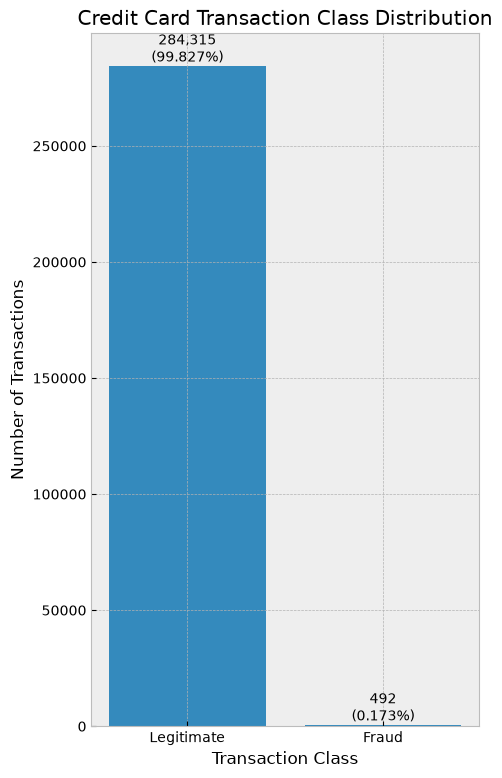

In [28]:
plt.figure(figsize=(5, 9))

bars = plt.bar(
    ["Legitimate", "Fraud"],
    class_counts.values
)

plt.title("Credit Card Transaction Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

for bar, count, percentage in zip(
    bars,
    class_counts.values,
    class_percentage.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.3f}%)",
        ha="center",
        va="bottom"
    )

plt.show()

### Visualizing Transaction Amount Distribution
We plot a histogram of the transaction amounts to see how they are distributed. Most transactions are likely to be of small amounts.

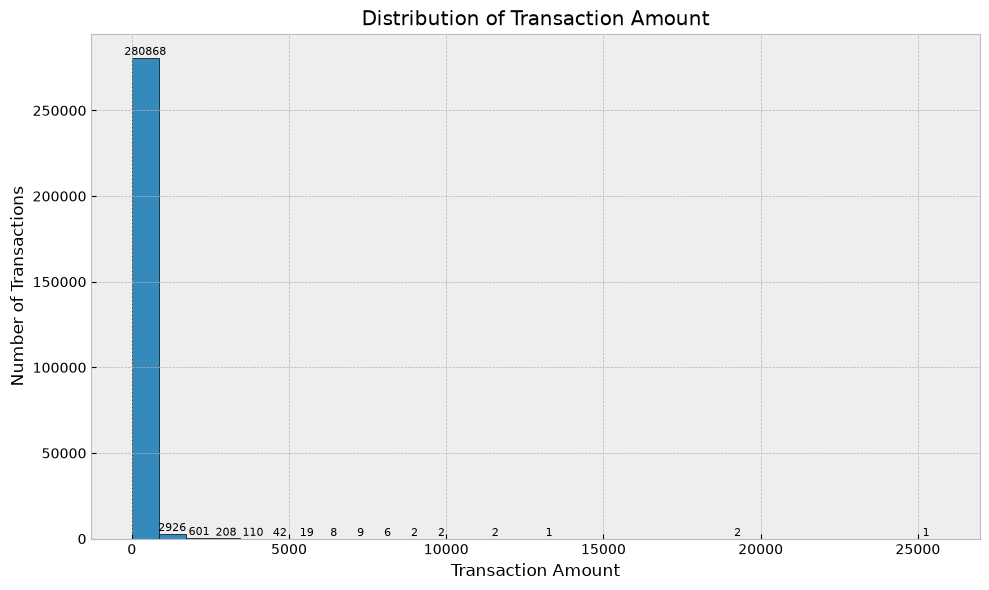

In [29]:
plt.figure(figsize=(10, 6))

counts, bins, patches = plt.hist(
    df["Amount"],
    bins=30,
    edgecolor="black"
)

# Add count values on top of bars
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

### Transaction Amount on a Log Scale
Since the transaction amounts are heavily skewed, we plot the histogram on a logarithmic scale to better visualize the distribution across different magnitudes.

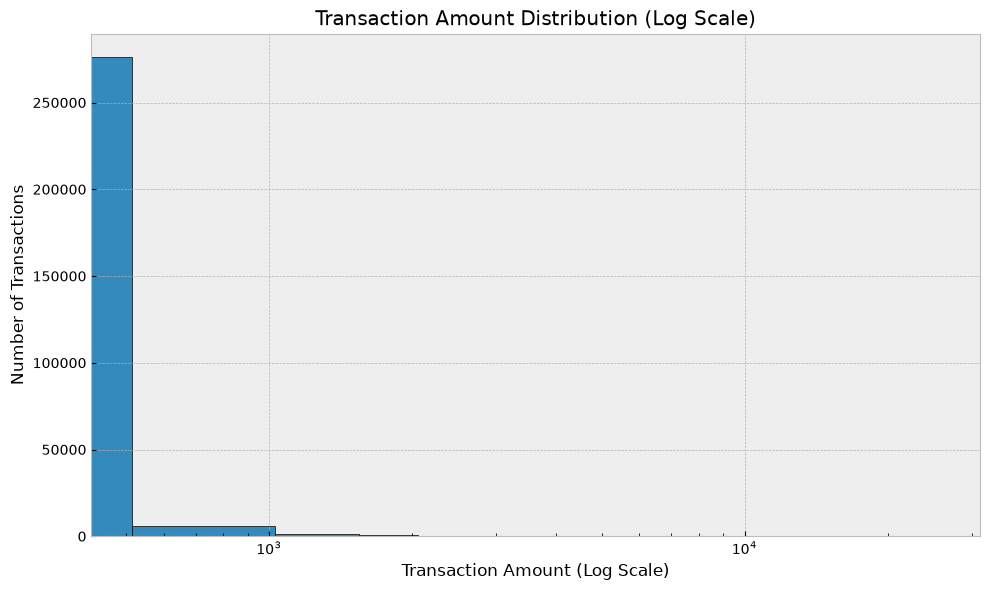

In [30]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Amount"],
    bins=50,
    edgecolor="black"
)

plt.xscale("log")

plt.title("Transaction Amount Distribution (Log Scale)")
plt.xlabel("Transaction Amount (Log Scale)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

### Transaction Amount by Class (Boxplot)
We use a boxplot to compare the distribution of transaction amounts between legitimate and fraudulent transactions. We limit the y-axis to focus on the core distribution.

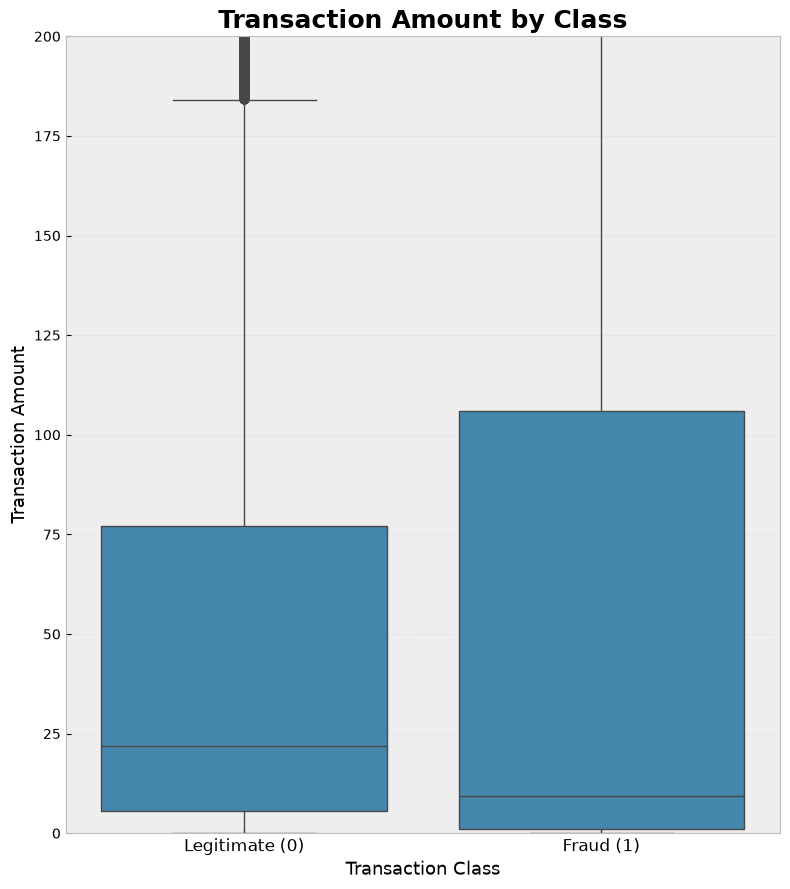

In [58]:
plt.figure(figsize=(8, 9))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class",
          fontsize=18, fontweight="bold")

plt.xlabel("Transaction Class", fontsize=13)
plt.ylabel("Transaction Amount", fontsize=13)

plt.xticks(
    [0, 1],
    ["Legitimate (0)", "Fraud (1)"],
    fontsize=12
)

# Limit only the visible Y-axis
plt.ylim(0, 200)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Distribution of Transactions Over Time
We plot a histogram of the `Time` feature to observe the frequency of transactions over the recorded time period (typically 48 hours).

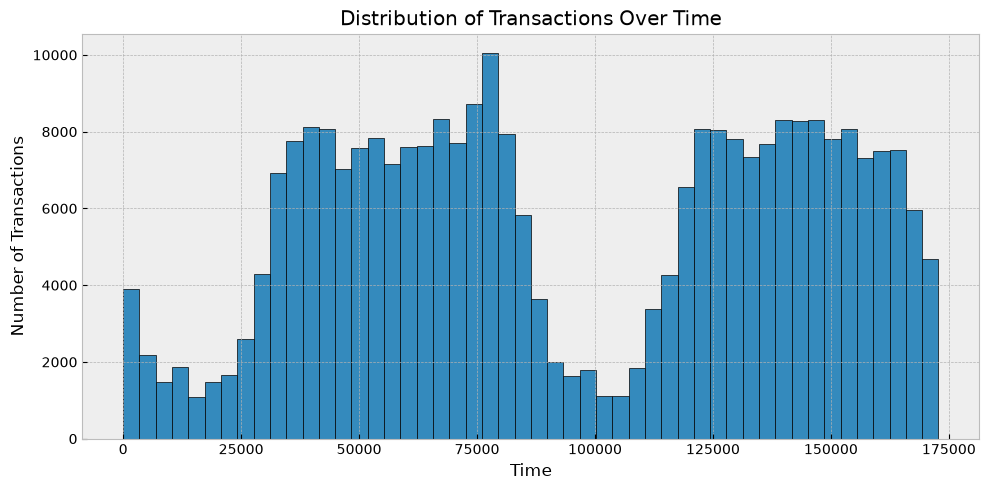

In [32]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["Time"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Transactions Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

### Transaction Amount vs Time by Class
We create a scatter plot to observe if there's any distinct pattern or correlation between the time of the transaction, the amount, and whether it was fraudulent.

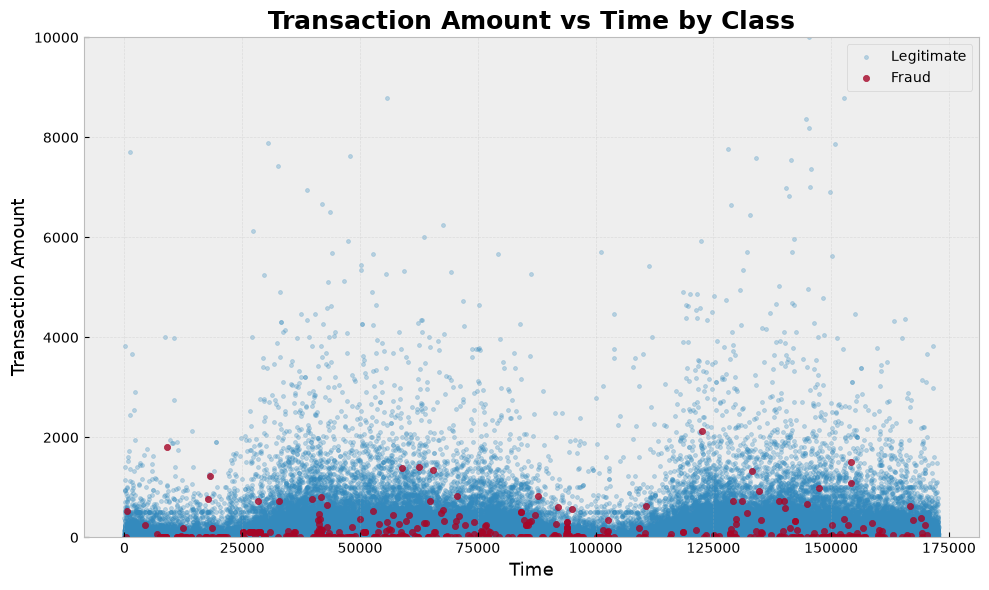

In [57]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df[df["Class"] == 0]["Time"],
    df[df["Class"] == 0]["Amount"],
    alpha=0.3,
    s=8,
    label="Legitimate"
)

plt.scatter(
    df[df["Class"] == 1]["Time"],
    df[df["Class"] == 1]["Amount"],
    alpha=0.8,
    s=20,
    label="Fraud"
)

plt.title(
    "Transaction Amount vs Time by Class",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Time", fontsize=13)
plt.ylabel("Transaction Amount", fontsize=13)

plt.ylim(0, 10000)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()